# <span>Worksheet - 3</span>
## <span>Modeling the Neuron: From MCP to Perceptron, Its Learning Algorithm, and Limitations
<small>

**Student Name:** Pratisha Bista  
**ID:** 2408284  
**Group:** L6CG1  

</small>

## 3.2 Task - 1: Implementation of MCP Neurons for AND and OR Function.

In [13]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1 nd array): An array of binary values.
    X2 (1 nd array): An array of binary values.
    Output:
    state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let’s name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    
    state_neuron = [1 if X1[i] + X2[i] > T else 0 for i in range(len(X1))]
    
    return state_neuron

In [14]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 0]


In [15]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    
    state_neuron = [1 if X1[i] + X2[i] > T else 0 for i in range(len(X1))]

    return state_neuron


In [16]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 0, 0, 1]



*Question - 1: List out all the limitations of MCP - Neurons.*

- The model is strictly limited to binary inputs and outputs (0 or 1). 
- It represents only a single unit and lacks the complex connectivity patterns found in biological neural networks.
- A single MCP neuron can only represent Boolean functions that are linearly separable.

*Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.*

- No, because it is limited to linear separability, the MCP neuron is incapable of implementing the XOR logical function since there must exist a line that can divide all "1" outputs from all "0" outputs.

## 4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification, Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


*Question - 3: What does the shape of X represent?*
- The shape of X represents the number of sample images in the dataset and the number of pixels per image.


*Question - 4: What does the shape of y represent?*
- The shape of y represents the number of labels (the target variable).

### Viewing the Dataset.

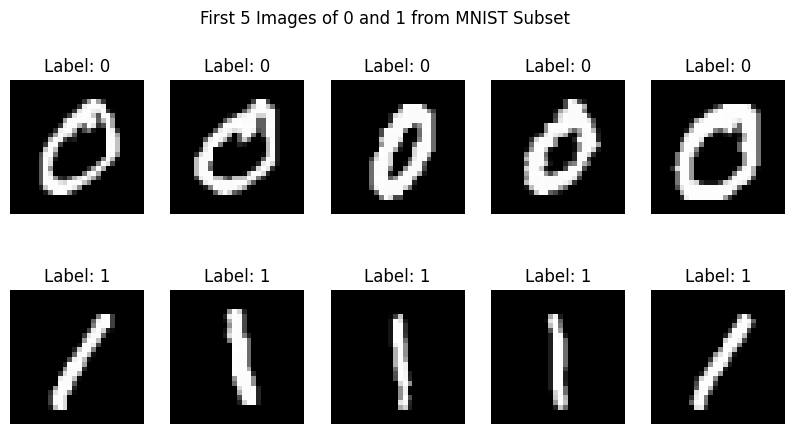

In [18]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [8]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

*Question - 5: What does the weights array represent in this context?*
- The weights array represents the learned importance of each pixel.

*Question - 6: Why are we initializing the weights to zero? What effect could this have on the training process?*
- So that we do not place any importance on any pixels to begin with. In the training process, there could be many updates on in the early epochs.

## Step - 3 - Make a Decision function:

In [9]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    # Activation function (step function)
    
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [10]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for _ in range(epochs):
        y_in = X.dot(weights) + bias
        y_pred = np.where(y_in >= 0, 1, 0)
        weights = weights + learning_rate * np.dot(X.T, y - y_pred)
        bias = bias + learning_rate * np.sum(y - y_pred)
    
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    
    return weights, bias, accuracy

*Question - 7: What is the purpose of the output = np.dot(X[i], weights) + bias line?*
- It computes the net weighted input (z) that determines the neuron's activation.

*Question - 8: What happens when the prediction is wrong? How are the weights and bias updated?*
-  When prediction is wrong, the weights and bias are updated using the update rule to correct the error.

*Question - 9:Why is the final accuracy important, and what do you expect it to be?*
- Final accuracy measures how well the model generalizes and whether the data is linearly separable.

## Training the Perceptron

In [11]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9973943939992104


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9974


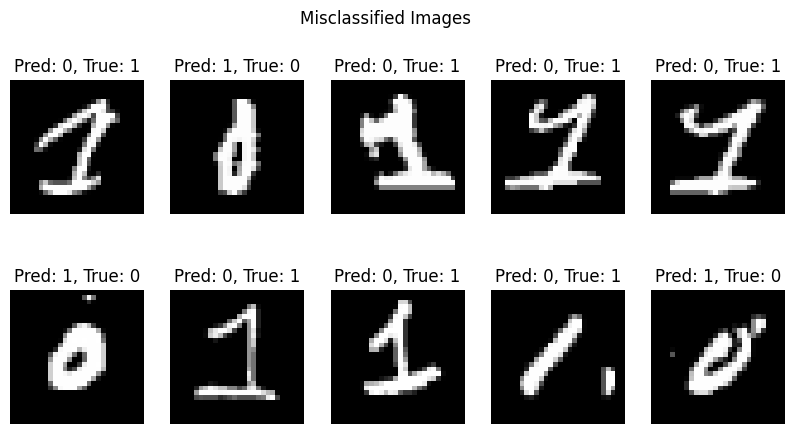

In [12]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

*Question - 10: What does misclassified idx store, and how is it used in this code?*
- misclassified_idx stores the indices (row numbers) of images that the model predicted incorrectly.
  
*Question - 11: How do you interpret the result if the output is ”All images were correctly classified!”?*
- That could mean that the data is linearly separable.


## 4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_3_5 = pd.read_csv("mnist_3_and_5.csv")

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

y_binary = np.where(y == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


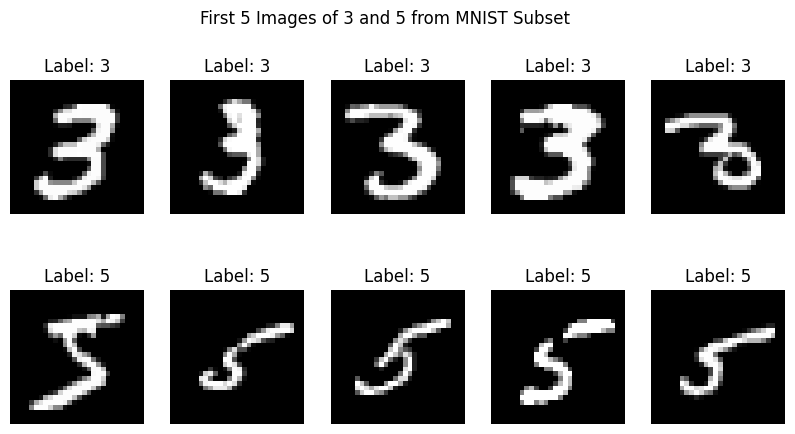

In [33]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10,5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [34]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

In [35]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0) 
    return y_pred_all

In [36]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for _ in range(epochs):
        y_in = X.dot(weights) + bias
        y_pred = np.where(y_in >= 0, 1, 0)
        weights = weights + learning_rate * np.dot(X.T, y - y_pred)
        bias = bias + learning_rate * np.sum(y - y_pred)
    
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    
    return weights, bias, accuracy

In [37]:
weights, bias, accuracy = train_perceptron(X, y_binary, weights, bias)

print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9576796789492886


Final Accuracy: 0.9577


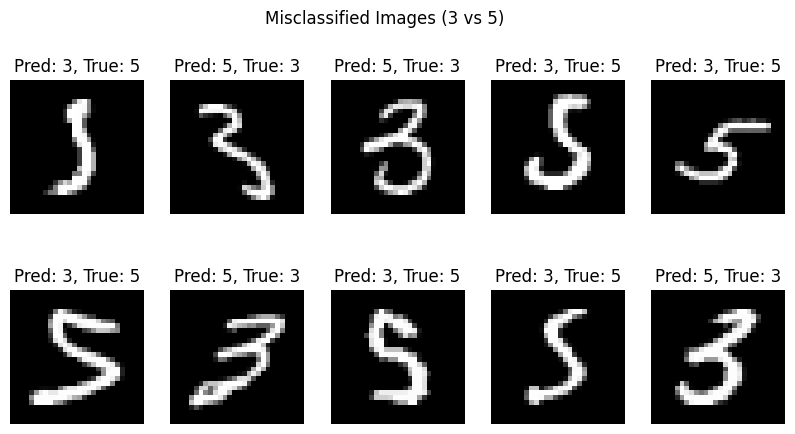

In [38]:
predictions = np.dot(X, weights) + bias
y_pred_binary = np.where(predictions >= 0, 1, 0)  

y_pred_original = np.where(y_pred_binary == 0, 3, 5)

final_accuracy = np.mean(y_pred_binary == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred_binary != y_binary)[0] 
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): 
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_original[idx]}, True: {y[idx]}") 
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")